# ModelV1 单样本推理可视化

从指定数据集随机选择一个样本，加载训练好的 ModelV1 checkpoint，完成一次推理，并显示：

1. 原始图像上的 face、left eye、right eye bounding boxes。
2. 固定物理坐标系中的 `gt_uv` 和 `pred_uv`。

本 Notebook 默认选择数据集 3 和 `outputs/notebook_training_validation/best.pt`。正式训练后只需要修改 checkpoint 路径。

## 1. 环境与项目路径

OpenMP 环境变量需要在导入 NumPy/PyTorch 前设置，以避免 Windows Conda 环境中多个 OpenMP runtime 冲突。

In [75]:
from __future__ import annotations

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import csv
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import yaml
from matplotlib.patches import Rectangle
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'modelv1').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modelv1.data.dataset import ModelV1Dataset
from modelv1.data.normalization import UVTargetNormalizer
from modelv1.inference import predict_uv_mm
from modelv1.model import ModelV1, ModelV1Config

print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.executable}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

Project root: D:\GithubCode\ModelV1
Python: d:\software\Anaconda\envs\3DGazeNet\python.exe
PyTorch: 2.0.1+cu118
CUDA available: True


## 2. 推理配置

`UV_XLIM` 和 `UV_YLIM` 是固定坐标范围。它们不会根据当前样本或预测结果变化。

In [76]:
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'modelv1' / 'train_random_80_20_100.yaml'
CSV_PATH = PROJECT_ROOT / 'data' / 'processed' / 'modelv1_dataset.csv'
DECA_CACHE_PATH = PROJECT_ROOT / 'data' / 'processed' / 'deca_features_v1.npz'
# CHECKPOINT_PATH = PROJECT_ROOT / 'outputs' / 'notebook_training_validation' / 'best.pt'
CHECKPOINT_PATH = PROJECT_ROOT / 'outputs' / 'ModelV1_random_80_20_100' / '20260716_193639' / 'checkpoints' / 'best.pt'

DATASET_NAME = '3'
SAMPLE_SEED = 20260716
DEVICE_NAME = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE = torch.device(DEVICE_NAME)

# Fixed table-local physical coordinate system, in millimeters.
UV_XLIM = (-400.0, 400.0)
UV_YLIM = (-650.0, 0.0)

with CONFIG_PATH.open('r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

if not CSV_PATH.exists():
    raise FileNotFoundError(f'Dataset CSV not found: {CSV_PATH}')
if not DECA_CACHE_PATH.exists():
    raise FileNotFoundError(f'DECA feature cache not found: {DECA_CACHE_PATH}')
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f'Checkpoint not found: {CHECKPOINT_PATH}. '
        'Please set CHECKPOINT_PATH to a trained best.pt.'
    )

print(f'Dataset: {DATASET_NAME}')
print(f'Checkpoint: {CHECKPOINT_PATH}')
print(f'Device: {DEVICE}')
print(f'Fixed UV x range: {UV_XLIM} mm')
print(f'Fixed UV y range: {UV_YLIM} mm')

Dataset: 3
Checkpoint: D:\GithubCode\ModelV1\outputs\ModelV1_random_80_20_100\20260716_193639\checkpoints\best.pt
Device: cuda
Fixed UV x range: (-400.0, 400.0) mm
Fixed UV y range: (-650.0, 0.0) mm


## 3. 加载 checkpoint 与 UV 归一化参数

兼容两种已有 checkpoint 格式：训练脚本保存的 `model`，以及验证 Notebook 保存的 `model_state_dict`。预测结果会使用 checkpoint 中保存的训练集 UV normalizer 反归一化到毫米。

In [77]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

with CONFIG_PATH.open('r', encoding='utf-8') as f:
    config_from_file = yaml.safe_load(f)

model_config_dict = dict(config_from_file['model'])
if 'model_config' in checkpoint:
    model_config_dict.update(checkpoint['model_config'])
elif isinstance(checkpoint.get('config'), dict):
    model_config_dict.update(checkpoint['config'].get('model', {}))
for key in ('face_hidden_dims', 'crop_cam_hidden_dims', 'scene_hidden_dims', 'fusion_hidden_dims'):
    model_config_dict[key] = tuple(model_config_dict[key])

model = ModelV1(ModelV1Config(**model_config_dict)).to(DEVICE)
state_dict = checkpoint.get('model', checkpoint.get('model_state_dict'))
if state_dict is None:
    raise KeyError("Checkpoint must contain 'model' or 'model_state_dict'.")
model.load_state_dict(state_dict)
model.eval()

normalizer_state = checkpoint.get('normalizer')
if normalizer_state is None:
    raise KeyError("Checkpoint does not contain the UV normalizer state.")
normalizer = UVTargetNormalizer.from_state_dict(normalizer_state)

print(f'Loaded checkpoint epoch: {checkpoint.get("epoch", "unknown")}')
print(f'Model parameters: {sum(parameter.numel() for parameter in model.parameters()):,}')
print(f'UV normalizer mean [mm]: {normalizer.mean_mm.tolist()}')
print(f'UV normalizer std [mm]: {normalizer.std_mm.tolist()}')

Loaded checkpoint epoch: 282
Model parameters: 492,884
UV normalizer mean [mm]: [-9.95582389831543, -274.57733154296875]
UV normalizer std [mm]: [147.85464477539062, 128.44775390625]


## 4. 随机选择一个样本并完成推理

数据集类会读取 eye crop、crop/camera 向量、scene 向量和离线 DECA 236-D 特征。原始 face 图像不进入当前模型，只用于后续画框显示。

In [78]:
with CSV_PATH.open('r', encoding='utf-8-sig', newline='') as f:
    csv_rows = list(csv.DictReader(f))

dataset_key = f'dataset_dual_rigid_body_{DATASET_NAME}'
candidate_rows = [row for row in csv_rows if row['dataset'] == dataset_key]
if not candidate_rows:
    raise ValueError(f'No samples found for DATASET_NAME={DATASET_NAME!r}')

# rng = random.Random(SAMPLE_SEED)
rng = random.Random()
selected_row = rng.choice(candidate_rows)
selected_sample_id = selected_row['sample_id']

sample_dataset = ModelV1Dataset(
    csv_path=CSV_PATH,
    datasets=[DATASET_NAME],
    normalize_images=True,
    load_face_image=False,
    return_paths=False,
    deca_cache_path=DECA_CACHE_PATH,
    require_deca_features=True,
    target_normalizer=normalizer,
    fit_target_normalizer=False,
)
sample_index = next(
    index for index, row in enumerate(sample_dataset.rows)
    if row['sample_id'] == selected_sample_id
)
sample = sample_dataset[sample_index]
sample_batch = {
    key: value.unsqueeze(0) if torch.is_tensor(value) else value
    for key, value in sample.items()
}
sample_batch = {
    key: value.to(DEVICE) if torch.is_tensor(value) else value
    for key, value in sample_batch.items()
}
pred_uv_mm = predict_uv_mm(model, sample_batch, normalizer).squeeze(0).cpu()
gt_uv_mm = sample['uv_gt'].cpu()
epe_mm = torch.linalg.vector_norm(pred_uv_mm - gt_uv_mm).item()

print(f"sample_id: {selected_row['sample_id']}")
print(f"image_name: {selected_row['image_name']}")
print(f"gt_uv [mm]:   [{gt_uv_mm[0].item():.2f}, {gt_uv_mm[1].item():.2f}]")
print(f"pred_uv [mm]: [{pred_uv_mm[0].item():.2f}, {pred_uv_mm[1].item():.2f}]")
print(f"EPE [mm]: {epe_mm:.2f}")
print('Input dimensions:')
for key in ('deca_feat', 'left_eye', 'right_eye', 'crop_cam_vec', 'scene_vec'):
    print(f'  {key}: {tuple(sample_batch[key].shape)}')

sample_id: dataset_dual_rigid_body_3/img_20260422_152857_00356
image_name: img_20260422_152857_00356.jpg
gt_uv [mm]:   [245.71, -404.46]
pred_uv [mm]: [245.69, -401.05]
EPE [mm]: 3.41
Input dimensions:
  deca_feat: (1, 236)
  left_eye: (1, 3, 36, 60)
  right_eye: (1, 3, 36, 60)
  crop_cam_vec: (1, 36)
  scene_vec: (1, 25)


## 5. 原始图像与 face/eye 框

框坐标来自 CSV，使用原始图像坐标系 `(x, y, w, h)` 绘制。

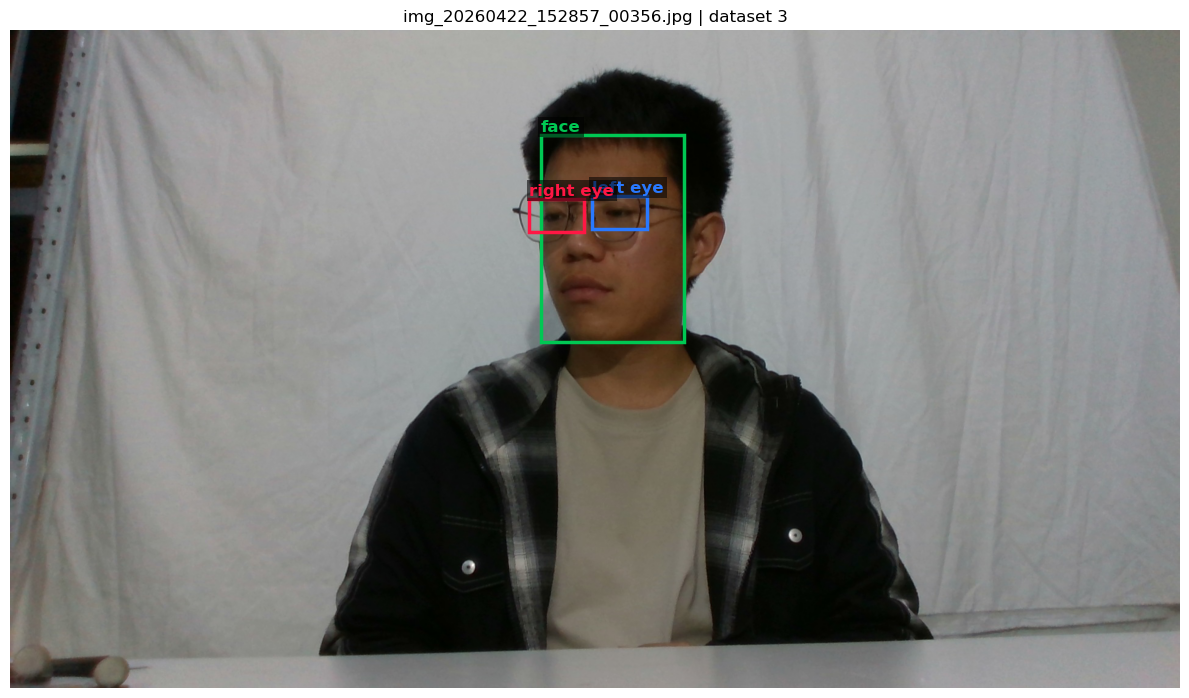

In [79]:
source_image_path = Path(selected_row['source_image_path'])
if not source_image_path.exists():
    raise FileNotFoundError(f'Source image not found: {source_image_path}')

source_image = Image.open(source_image_path).convert('RGB')
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(source_image)
box_specs = (
    ('face', 'face_bbox', '#00c853'),
    ('left eye', 'left_eye_bbox', '#2979ff'),
    ('right eye', 'right_eye_bbox', '#ff1744'),
)
for label, prefix, color in box_specs:
    x = float(selected_row[f'{prefix}_x'])
    y = float(selected_row[f'{prefix}_y'])
    width = float(selected_row[f'{prefix}_w'])
    height = float(selected_row[f'{prefix}_h'])
    ax.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=2.5, edgecolor=color))
    ax.text(x, max(0, y - 6), label, color=color, fontsize=12, weight='bold',
            bbox=dict(facecolor='black', alpha=0.55, edgecolor='none', pad=2))

ax.set_title(f"{selected_row['image_name']} | dataset {DATASET_NAME}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. 固定坐标系中的 GT UV 与预测 UV

坐标单位为毫米。坐标范围固定为 `u=[-400,400]`、`v=[-650,0]`，两个点始终在同一坐标系中显示。

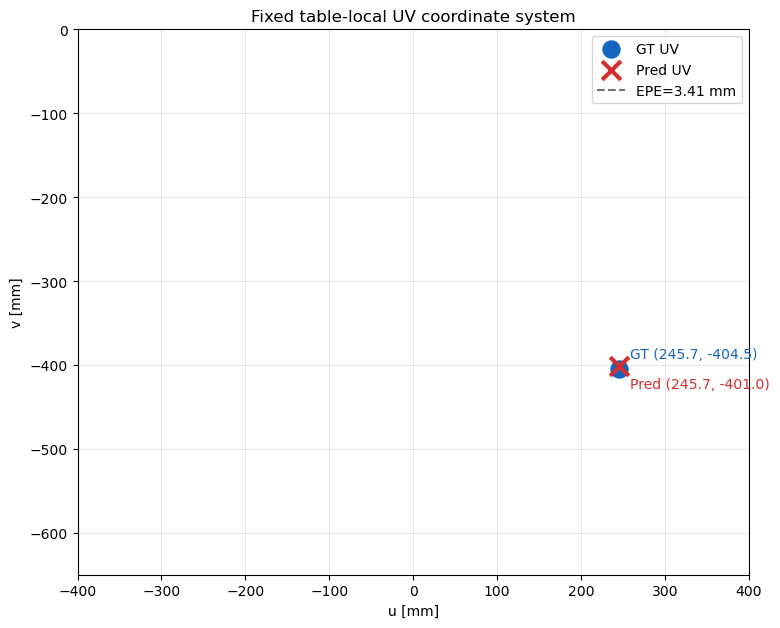

In [80]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(gt_uv_mm[0], gt_uv_mm[1], s=150, marker='o', color='#1565c0', label='GT UV', zorder=3)
ax.scatter(pred_uv_mm[0], pred_uv_mm[1], s=180, marker='x', color='#d32f2f', linewidths=3, label='Pred UV', zorder=4)
ax.plot([gt_uv_mm[0], pred_uv_mm[0]], [gt_uv_mm[1], pred_uv_mm[1]],
        linestyle='--', linewidth=1.5, color='#757575', label=f'EPE={epe_mm:.2f} mm')
ax.annotate(f'GT ({gt_uv_mm[0]:.1f}, {gt_uv_mm[1]:.1f})', (gt_uv_mm[0], gt_uv_mm[1]),
            xytext=(8, 8), textcoords='offset points', color='#1565c0')
ax.annotate(f'Pred ({pred_uv_mm[0]:.1f}, {pred_uv_mm[1]:.1f})', (pred_uv_mm[0], pred_uv_mm[1]),
            xytext=(8, -16), textcoords='offset points', color='#d32f2f')
ax.set_xlim(*UV_XLIM)
ax.set_ylim(*UV_YLIM)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('u [mm]')
ax.set_ylabel('v [mm]')
ax.set_title('Fixed table-local UV coordinate system')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()